# Check color augmentation

The idea is to have a very simple generator to create sufficient playground for method testing

In [1]:
import meatballsss as mbs
import numpy as np
import matplotlib.pyplot as plt

In [2]:
radii = [20,50]
seed_nums = [1,100]

agglomerate = mbs.VoxelizedMeatball()
agglomerate.create_structured_agglomerate(radii, seed_nums)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:94: UserWarning: Empty initialization. Please generate a grain structure!
  warnings.warn("Empty initialization. Please generate a grain structure!")


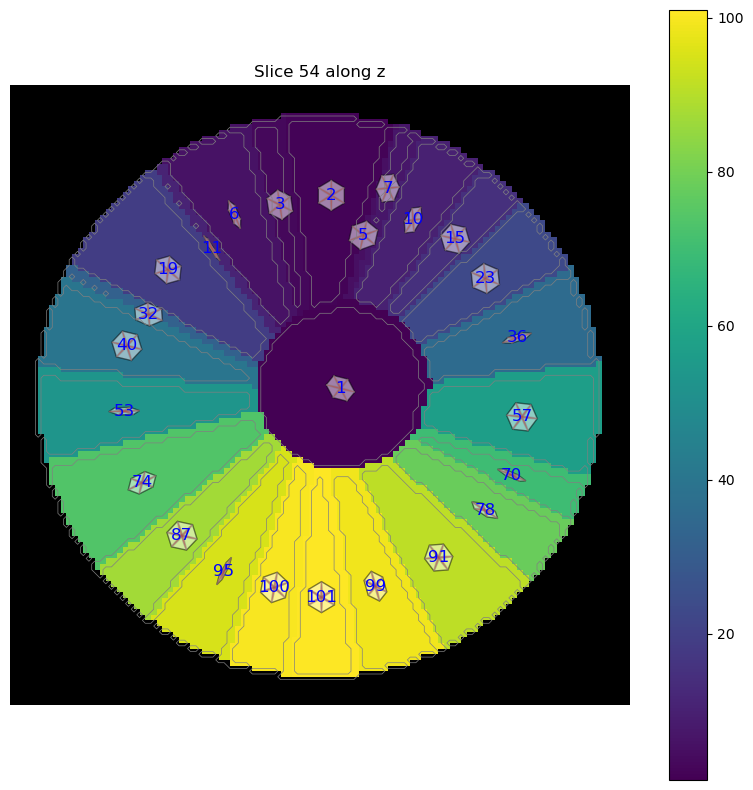

In [3]:
%matplotlib inline
agglomerate.plot_slice_with_orientations(54, direction= 'z', show_ids=True, colormap='viridis')

In [4]:
# mbs.plot_global_grain_alignment(agglomerate)

Explore some more comfort features of the meatball object

Generating colormap from grain_map and angle_list.


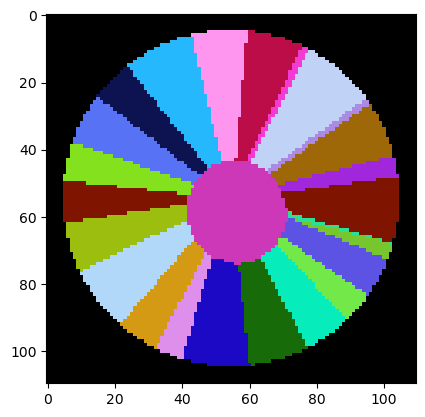

In [5]:
colormap = agglomerate.generate_color_map()
plt.figure()
im = plt.imshow(colormap[:,:,54])

In [6]:
pairs, dot_products = mbs.evaluate_relative_grain_alignment(agglomerate)

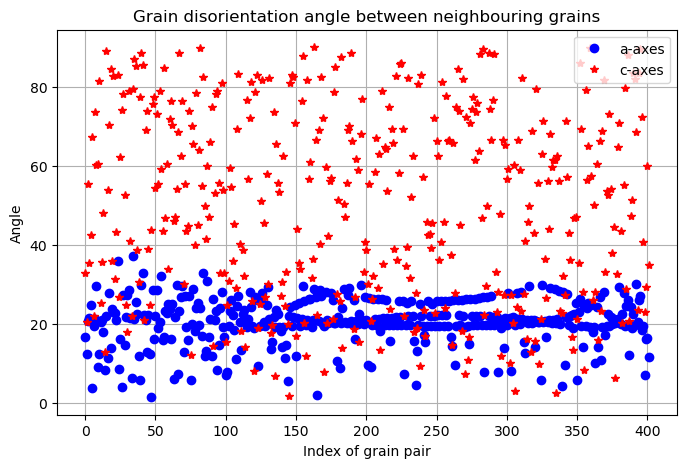

In [7]:
mbs.plot_relative_grain_alignment(agglomerate)

### Test color augmentation on center slice

Create new meatball object from center slice of previous agglomerate

In [8]:
center_slice = agglomerate.fields['grains'][:,:,54]
slice_labels = np.unique(center_slice)
# Remove background label 0
slice_labels = slice_labels[slice_labels > 0]
visible_angles = agglomerate.angles[slice_labels - 1]

agglomerate2 = mbs.VoxelizedMeatball(grain_map=center_slice, angle_list=visible_angles)

Check visually if this is consistent with previous data

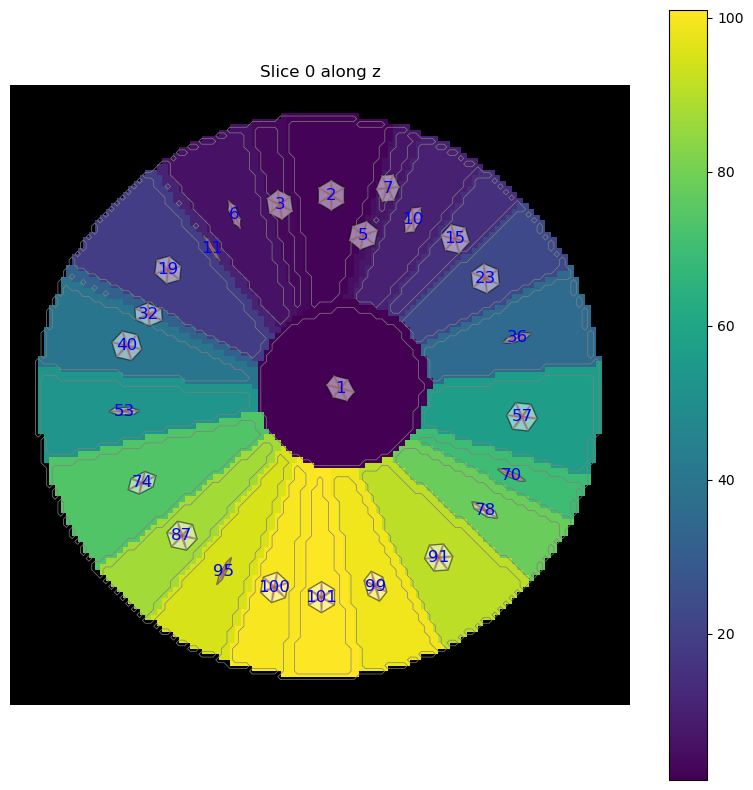

In [9]:
agglomerate2.plot_slice_with_orientations(0, show_ids=True, colormap='viridis')

In [10]:
pairs2, dot_products2 = mbs.evaluate_relative_grain_alignment(agglomerate2)

Function to check if the pairwise misorientations between grains are identical or not. So far we have just copied the angles, so it should always be identical.

In [11]:
def check_common_misorientations(pairs, dot_products, pairs2, dot_products2, tol=1e-6):
    """
    Checks that the misorientation values (e.g., dot products) for phase pairs 
    that are common between the 3D and 2D data are identical (within a tolerance).
    
    Parameters:
      pairs (np.ndarray): Array of shape (N,2) for the 3D data.
      dot_products (np.ndarray): 1D array of misorientation values corresponding to `pairs`.
      pairs2 (np.ndarray): Array of shape (M,2) for the 2D data.
      dot_products2 (np.ndarray): 1D array of misorientation values corresponding to `pairs2`.
      tol (float): Tolerance for numerical comparison.
    
    Returns:
      bool: True if all common pairs have misorientation values that agree (within tol); 
            otherwise, False.
    """
    flag = True
    # Convert each pair into a tuple. Since the pairs are already sorted (first element is smaller),
    # (a, b) and (b, a) are the same.
    set_pairs = {tuple(row) for row in pairs}
    set_pairs2 = {tuple(row) for row in pairs2}
    
    # Find the common phase pairs between the 3D and 2D data
    common_pairs = set_pairs.intersection(set_pairs2)
    
    # Build dictionaries mapping each phase pair to its misorientation value
    dict3d = {tuple(pairs[i]): dot_products[i] for i in range(len(pairs))}
    dict2d = {tuple(pairs2[i]): dot_products2[i] for i in range(len(pairs2))}
    
    # Now, for each common pair, check that the misorientations agree within the given tolerance.
    for pair in common_pairs:
        val3d = dict3d[pair]
        val2d = dict2d[pair]
        if not np.isclose(val3d, val2d, atol=tol):
            #print(f"Mismatch for pair {pair}: 3D={val3d}, 2D={val2d}")
            flag = False
    return flag

result = check_common_misorientations(pairs, dot_products[:,0], pairs2, dot_products2[:,0], tol=1e-6)
print("Common misorientations match:", result)

Common misorientations match: True


Write function to modify angles based on global rotation matrix

In [ ]:
from scipy.spatial.transform import Rotation as rot

def normalize_angles(raw_angles):
    norm_angles = np.copy(raw_angles)
    change_signs = norm_angles[:,0]<0
    norm_angles[change_signs, 0] += 180
    norm_angles[change_signs, 1] *= -1

    change_signs = norm_angles[:,1]<0
    norm_angles[change_signs, 1] += 180
    norm_angles[change_signs, 2] *= -1

    norm_angles[norm_angles[:,2]<0, 2] += 120
    norm_angles[norm_angles[:,2]<0, 2] += 120
    norm_angles[norm_angles[:,2]>=120, 2] -= 120
    
    return norm_angles

def modify_angles(angles, rotation):
    """
    Modify the Euler angles (in 'ZXZ' convention, degrees) by applying a rotation matrix.
    """
    new_angles = np.zeros_like(angles)
    for i in range(angles.shape[0]):
        # Compute the original rotation matrix from the Euler angles
        R0 = rot.from_euler('ZXZ', angles[i], degrees=True).as_matrix()
        # Apply the given rotation matrix to the original rotation
        new_R = rotation @ R0
        # Convert the resulting rotation matrix back to Euler angles in 'ZXZ' convention
        new_angles[i] = rot.from_matrix(new_R).as_euler('ZXZ', degrees=True)
    new_angles = normalize_angles(new_angles) # in range [180,180,120]
    return new_angles

In [ ]:
random_angles = np.random.rand(3)*360
# R = rot.from_euler('z', 10, degrees=True).as_matrix()
R = rot.from_euler('ZYX', random_angles, degrees=True).as_matrix()

new_angles = modify_angles(agglomerate2.angles, R)
# new_angles = np.copy(agglomerate2.angles)
# new_angles[:,2] -= 123

In [31]:
agglomerate3 = mbs.VoxelizedMeatball(grain_map=agglomerate2.fields['grains'], angle_list=new_angles)
pairs3, dot_products3 = mbs.evaluate_relative_grain_alignment(agglomerate3)

match_a = check_common_misorientations(pairs3, dot_products3[:,0], pairs2, dot_products2[:,0], tol=1e-6)
match_b = check_common_misorientations(pairs3, dot_products3[:,1], pairs2, dot_products2[:,1], tol=1e-6)
match_c = check_common_misorientations(pairs3, dot_products3[:,2], pairs2, dot_products2[:,2], tol=1e-6)
print("Common misorientations match:", match_a, match_b, match_c)

Common misorientations match: True True True


Generating colormap from grain_map and angle_list.


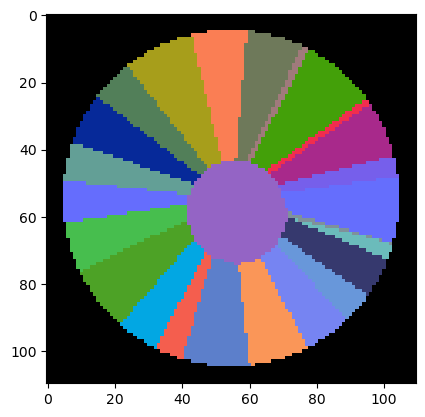

In [32]:
colormap = agglomerate3.generate_color_map()
plt.figure()
im = plt.imshow(colormap[:,:,0])